In [1]:

# Install & Import
!pip install kagglehub --quiet

import os, shutil, time, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)
from skimage.feature import hog

import tensorflow as tf
from tensorflow.keras import layers, models
import joblib

In [2]:
# ─────────────────────────────────────────────
# Mount Drive & Download Dataset
# ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import kagglehub
path = kagglehub.dataset_download("olgabelitskaya/flower-color-images")
print("Path dataset:", path)

Mounted at /content/drive


100%|██████████| 50.1M/50.1M [00:00<00:00, 191MB/s]

Extracting files...


Path dataset: /root/.cache/kagglehub/datasets/olgabelitskaya/flower-color-images/versions/7


In [3]:
# ─────────────────────────────────────────────
# CELL 3 — Konfigurasi Path
# ─────────────────────────────────────────────
DATASET_DIR = path
OUTPUT_DIR  = "/content/drive/MyDrive/Tugas 3/output 2"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ["merah", "orange", "kuning", "biru", "ungu", "pink", "putih"]
IMG_SIZE    = 128

print(f"Dataset : {DATASET_DIR}")
print(f"Output  : {OUTPUT_DIR}")

Dataset : /root/.cache/kagglehub/datasets/olgabelitskaya/flower-color-images/versions/7
Output  : /content/drive/MyDrive/Tugas 3/output 2


In [4]:
# ─────────────────────────────────────────────
# CELL 4 — Fungsi Pelabelan HSV
# ─────────────────────────────────────────────
COLOR_RANGES = {
    "merah":  [(np.array([0,   120,  80]), np.array([8,   255, 255])),
               (np.array([172, 120,  80]), np.array([179, 255, 255]))],
    "orange": [(np.array([9,   120,  80]), np.array([20,  255, 255]))],
    "kuning": [(np.array([21,  100,  80]), np.array([35,  255, 255]))],
    "biru":   [(np.array([90,   60,  50]), np.array([125, 255, 255]))],
    "ungu":   [(np.array([126,  40,  40]), np.array([148, 255, 255]))],
    "pink":   [(np.array([149,  40,  80]), np.array([171, 255, 255]))],
    "putih":  [(np.array([0,     0, 190]), np.array([179,  30, 255]))],
}

def get_flower_mask(img):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(mask, (w//2, h//2), (w//3, h//3), 0, 0, 360, 255, -1)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    green = cv2.inRange(hsv, np.array([36, 40,  40]), np.array([85,  255, 255]))
    sky   = cv2.inRange(hsv, np.array([90, 30, 150]), np.array([130, 255, 255]))
    exclude = cv2.bitwise_or(green, sky)
    return cv2.bitwise_and(mask, cv2.bitwise_not(exclude))

def label_image(img):
    hsv   = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    fmask = get_flower_mask(img)
    scores = {}
    for name, ranges in COLOR_RANGES.items():
        total = 0
        for lo, hi in ranges:
            m = cv2.inRange(hsv, lo, hi)
            total += cv2.countNonZero(cv2.bitwise_and(m, fmask))
        scores[name] = total
    sorted_s = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top1_name, top1_val = sorted_s[0]
    top2_val = sorted_s[1][1]
    if top1_val < 300 or (top2_val > 0 and top1_val / top2_val < 1.5):
        return None
    return top1_name

In [5]:
# ─────────────────────────────────────────────
# CELL 5 — Load & Labeling Dataset
# ─────────────────────────────────────────────
images, labels = [], []
skipped = 0

all_files = []
for root, dirs, files_in in os.walk(DATASET_DIR):
    for fname in files_in:
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            all_files.append(os.path.join(root, fname))

print(f"Total file ditemukan: {len(all_files)}")

for fpath in all_files:
    img = cv2.imread(fpath)
    if img is None:
        continue
    img   = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    label = label_image(img)
    if label is None:
        skipped += 1
        continue
    images.append(img)
    labels.append(CLASS_NAMES.index(label))

images = np.array(images)
labels = np.array(labels)

print(f"\nTotal terlabel       : {len(images)}")
print(f"Tidak terklasifikasi : {skipped}")
print("\nDistribusi kelas:")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:8s}: {np.sum(labels == i)}")

Total file ditemukan: 813

Total terlabel       : 729
Tidak terklasifikasi : 84

Distribusi kelas:
  merah   : 79
  orange  : 57
  kuning  : 136
  biru    : 12
  ungu    : 73
  pink    : 147
  putih   : 225


In [6]:
# ─────────────────────────────────────────────
# CELL 6 — Train/Test Split 80:20
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
print(f"Train : {len(X_train)}")
print(f"Test  : {len(X_test)}")

Train : 583
Test  : 146


In [7]:
# ─────────────────────────────────────────────
# CELL 7 — Metode Klasik: SVM + HOG dan SVM + HSV Histogram
# ─────────────────────────────────────────────
# Catatan:
# - SVM + HOG digunakan sebagai baseline fitur bentuk/tekstur.
# - SVM + HSV Histogram digunakan sebagai metode klasik utama untuk klasifikasi warna.


def extract_hog(imgs):
    """Ekstraksi fitur HOG dari citra grayscale."""
    features = []

    for img in imgs:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            visualize=False
        )
        features.append(feat)

    return np.array(features)


def extract_hsv_histogram(imgs, h_bins=32, s_bins=16, v_bins=16):
    """Ekstraksi fitur histogram HSV untuk merepresentasikan distribusi warna."""
    features = []

    for img in imgs:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        hist_h = cv2.calcHist([hsv], [0], None, [h_bins], [0, 180])
        hist_s = cv2.calcHist([hsv], [1], None, [s_bins], [0, 256])
        hist_v = cv2.calcHist([hsv], [2], None, [v_bins], [0, 256])

        hist = np.concatenate([
            hist_h.flatten(),
            hist_s.flatten(),
            hist_v.flatten()
        ])

        # Normalisasi agar fitur tidak bergantung pada jumlah piksel.
        hist = hist / (hist.sum() + 1e-8)
        features.append(hist)

    return np.array(features)


# ── SVM + HOG ───────────────────────────────
print("Ekstraksi HOG — training set...")
X_train_hog = extract_hog(X_train)
print("Ekstraksi HOG — test set...")
X_test_hog = extract_hog(X_test)
print(f"Dimensi fitur HOG : {X_train_hog.shape[1]}")

svm_hog_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale", probability=True))
])

print("\nTraining SVM + HOG...")
t0 = time.time()
svm_hog_pipeline.fit(X_train_hog, y_train)
svm_hog_train_time = time.time() - t0
print(f"Selesai. Waktu training : {svm_hog_train_time:.2f} detik")

t0 = time.time()
y_pred_svm_hog = svm_hog_pipeline.predict(X_test_hog)
svm_hog_infer_time = (time.time() - t0) / len(X_test)
print(f"Waktu inferensi per gambar : {svm_hog_infer_time * 1000:.4f} ms")


# ── SVM + HSV Histogram ─────────────────────
print("\nEkstraksi HSV Histogram — training set...")
X_train_hsv = extract_hsv_histogram(X_train)
print("Ekstraksi HSV Histogram — test set...")
X_test_hsv = extract_hsv_histogram(X_test)
print(f"Dimensi fitur HSV Histogram : {X_train_hsv.shape[1]}")

svm_hsv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=True
    ))
])

print("\nTraining SVM + HSV Histogram...")
t0 = time.time()
svm_hsv_pipeline.fit(X_train_hsv, y_train)
svm_hsv_train_time = time.time() - t0
print(f"Selesai. Waktu training : {svm_hsv_train_time:.2f} detik")

t0 = time.time()
y_pred_svm_hsv = svm_hsv_pipeline.predict(X_test_hsv)
svm_hsv_infer_time = (time.time() - t0) / len(X_test)
print(f"Waktu inferensi per gambar : {svm_hsv_infer_time * 1000:.4f} ms")

# Alias lama agar cell lain yang masih memakai nama lama tidak langsung rusak.
# Model utama klasik tetap SVM + HSV Histogram untuk pembahasan warna.
svm_pipeline = svm_hog_pipeline
y_pred_svm = y_pred_svm_hog
svm_train_time = svm_hog_train_time
svm_infer_time = svm_hog_infer_time


Ekstraksi HOG — training set...
Ekstraksi HOG — test set...
Dimensi fitur HOG : 8100

Training SVM + HOG...
Selesai. Waktu training : 13.56 detik
Waktu inferensi per gambar : 4.1063 ms

Ekstraksi HSV Histogram — training set...
Ekstraksi HSV Histogram — test set...
Dimensi fitur HSV Histogram : 64

Training SVM + HSV Histogram...
Selesai. Waktu training : 0.09 detik
Waktu inferensi per gambar : 0.0548 ms


In [8]:
# ─────────────────────────────────────────────
# CELL 8 — Metode 2: CNN Sederhana
# ─────────────────────────────────────────────
def build_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

X_train_rgb = X_train[..., ::-1].astype(np.float32)
X_test_rgb  = X_test[..., ::-1].astype(np.float32)

cnn_model = build_cnn(len(CLASS_NAMES))
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

print("\nTraining CNN...")
t0 = time.time()
history = cnn_model.fit(
    X_train_rgb, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)
cnn_train_time = time.time() - t0
print(f"\nSelesai. Waktu training : {cnn_train_time:.2f} detik")

t0 = time.time()
y_pred_cnn = np.argmax(cnn_model.predict(X_test_rgb, verbose=0), axis=1)
cnn_infer_time = (time.time() - t0) / len(X_test)
print(f"Waktu inferensi per gambar : {cnn_infer_time*1000:.4f} ms")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,559 (435.78 KB)

 Trainable params: 111,111 (434.03 KB)

 Non-trainable params: 448 (1.75 KB)


Training CNN...
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6679 - loss: 0.9922 - val_accuracy: 0.6271 - val_loss: 1.8742
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8683 - loss: 0.4589 - val_accuracy: 0.5254 - val_loss: 1.8186
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8855 - loss: 0.3741 - val_accuracy: 0.3898 - val_loss: 1.7620
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9256 - loss: 0.2731 - val_accuracy: 0.3559 - val_loss: 1.6923
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9275 - loss: 0.2462 - val_accuracy: 0.5763 - val_loss: 1.6707
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9332 - loss: 0.2339 - val_accuracy: 0.6102 - val_loss: 1.6125
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9332 - loss: 0.2280 - val_accuracy: 0.3220 - val_loss: 1.6156
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9218 - loss: 0.2529 - val_accuracy: 0

In [9]:
# ─────────────────────────────────────────────
# CELL 9 — Evaluasi & Tabel Ringkasan
# ─────────────────────────────────────────────
def print_metrics(name, y_true, y_pred, train_time, infer_time):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_w = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n{'=' * 56}")
    print(f"Model              : {name}")
    print(f"Akurasi            : {acc:.4f}")
    print(f"Precision Weighted : {prec:.4f}")
    print(f"Recall Weighted    : {rec:.4f}")
    print(f"F1-Score Weighted  : {f1_w:.4f}")
    print(f"F1-Score Macro     : {f1_macro:.4f}")
    print(f"Waktu Train        : {train_time:.2f}s")
    print(f"Waktu Infer        : {infer_time * 1000:.4f}ms/gambar")
    print(f"\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)}")

    return acc, prec, rec, f1_w, f1_macro


acc_svm_hog, prec_svm_hog, rec_svm_hog, f1_svm_hog, f1_macro_svm_hog = print_metrics(
    "SVM + HOG", y_test, y_pred_svm_hog, svm_hog_train_time, svm_hog_infer_time
)

acc_svm_hsv, prec_svm_hsv, rec_svm_hsv, f1_svm_hsv, f1_macro_svm_hsv = print_metrics(
    "SVM + HSV Histogram", y_test, y_pred_svm_hsv, svm_hsv_train_time, svm_hsv_infer_time
)

acc_cnn, prec_cnn, rec_cnn, f1_cnn, f1_macro_cnn = print_metrics(
    "CNN", y_test, y_pred_cnn, cnn_train_time, cnn_infer_time
)

print("\n" + "=" * 92)
print(f"{'Metrik':<24} {'SVM+HOG':>14} {'SVM+HSV':>14} {'CNN':>14}")
print("-" * 92)

for label, hog_value, hsv_value, cnn_value in [
    ("Akurasi", acc_svm_hog, acc_svm_hsv, acc_cnn),
    ("Precision Weighted", prec_svm_hog, prec_svm_hsv, prec_cnn),
    ("Recall Weighted", rec_svm_hog, rec_svm_hsv, rec_cnn),
    ("F1-Score Weighted", f1_svm_hog, f1_svm_hsv, f1_cnn),
    ("F1-Score Macro", f1_macro_svm_hog, f1_macro_svm_hsv, f1_macro_cnn),
    ("Train (s)", svm_hog_train_time, svm_hsv_train_time, cnn_train_time),
    ("Infer (ms/img)", svm_hog_infer_time * 1000, svm_hsv_infer_time * 1000, cnn_infer_time * 1000),
]:
    print(f"{label:<24} {hog_value:>14.4f} {hsv_value:>14.4f} {cnn_value:>14.4f}")



Model              : SVM + HOG
Akurasi            : 0.5890
Precision Weighted : 0.6663
Recall Weighted    : 0.5890
F1-Score Weighted  : 0.5768
F1-Score Macro     : 0.5084
Waktu Train        : 13.56s
Waktu Infer        : 4.1063ms/gambar

              precision    recall  f1-score   support

       merah       1.00      0.50      0.67        16
      orange       1.00      0.64      0.78        11
      kuning       0.62      0.48      0.54        27
        biru       0.00      0.00      0.00         2
        ungu       1.00      0.27      0.42        15
        pink       0.54      0.50      0.52        30
       putih       0.50      0.87      0.63        45

    accuracy                           0.59       146
   macro avg       0.66      0.46      0.51       146
weighted avg       0.67      0.59      0.58       146


Model              : SVM + HSV Histogram
Akurasi            : 0.9521
Precision Weighted : 0.9554
Recall Weighted    : 0.9521
F1-Score Weighted  : 0.9519
F1-Score Ma

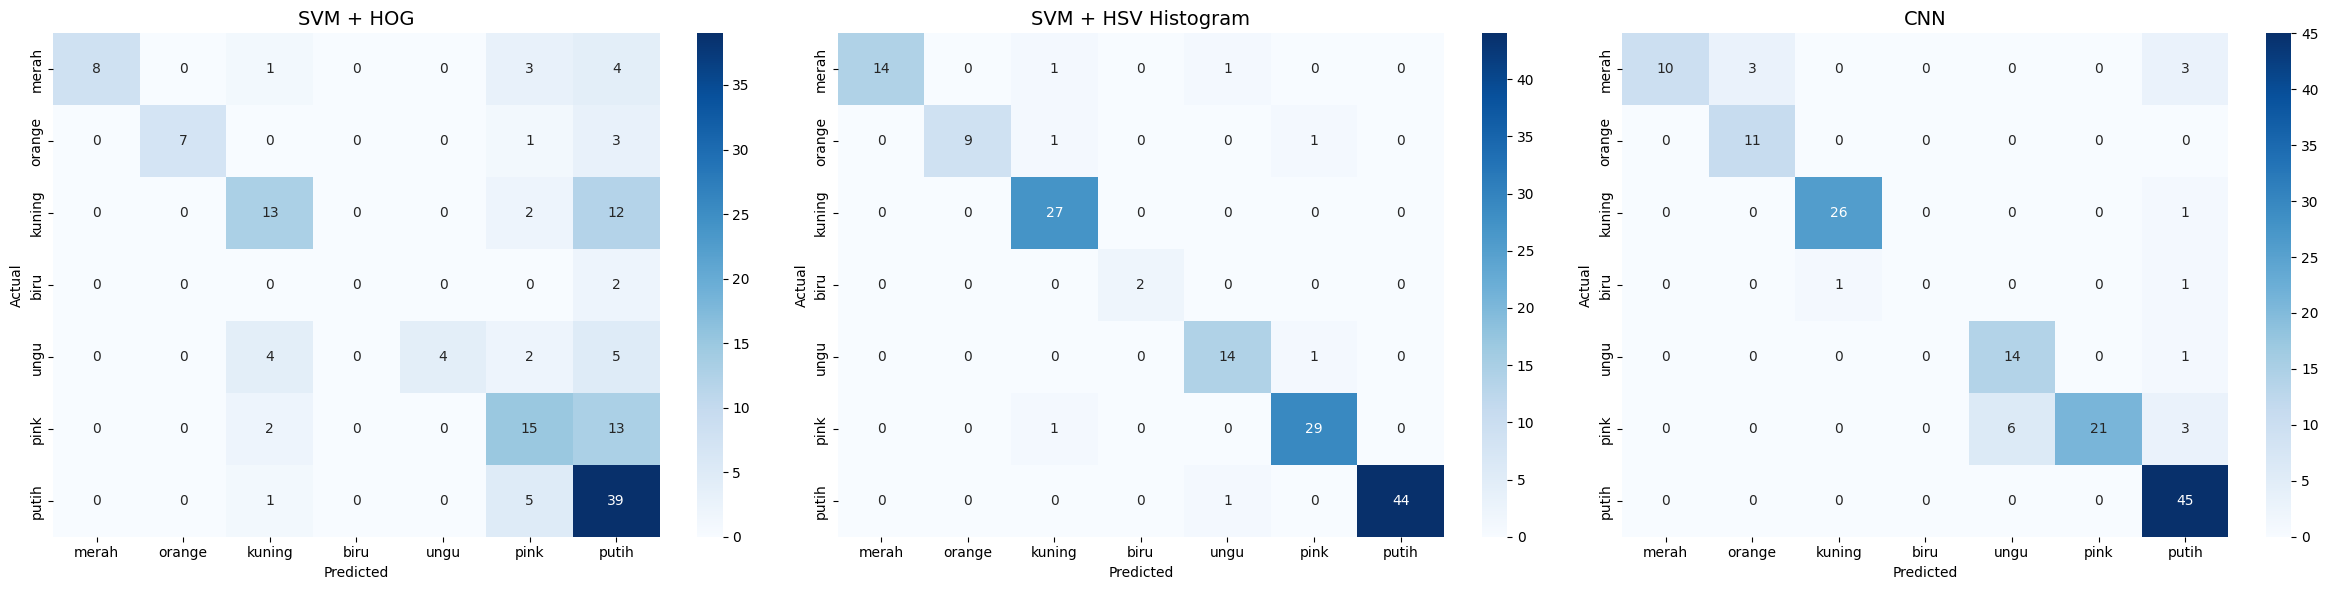

Disimpan: /content/drive/MyDrive/Tugas 3/output 2/confusion_matrix.png


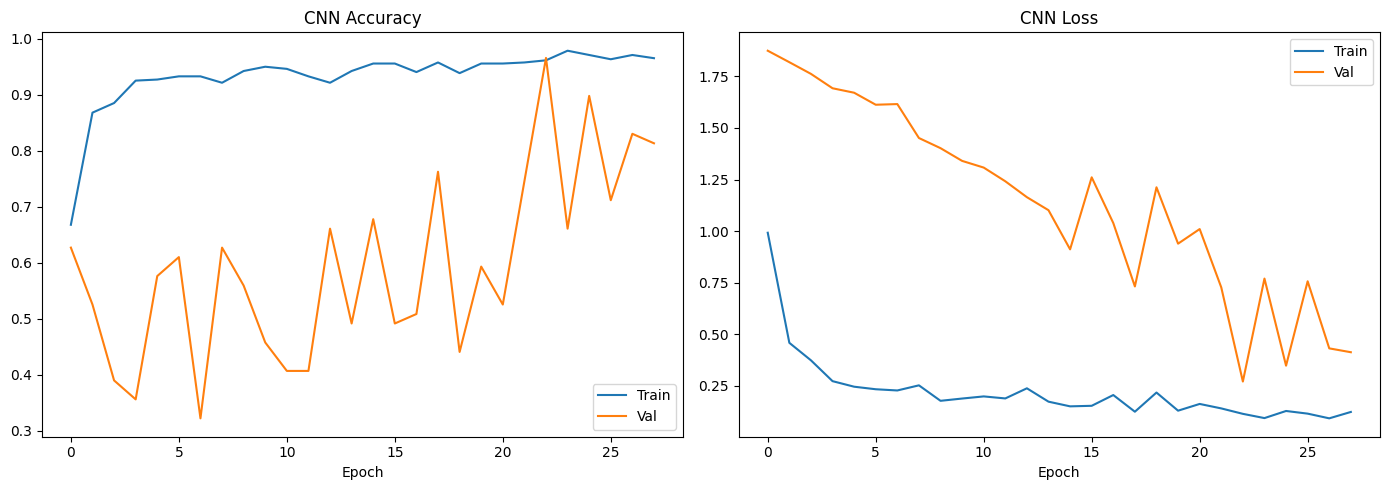

Disimpan: /content/drive/MyDrive/Tugas 3/output 2/cnn_training_history.png


In [10]:
# ─────────────────────────────────────────────
# CELL 10 — Confusion Matrix & Training History
# ─────────────────────────────────────────────
# Confusion matrix untuk tiga pendekatan klasifikasi.
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_svm_hog, y_pred_svm_hsv, y_pred_cnn],
    ["SVM + HOG", "SVM + HSV Histogram", "CNN"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        ax=ax,
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Disimpan: {cm_path}")

# Training history CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
hist_path = os.path.join(OUTPUT_DIR, "cnn_training_history.png")
plt.savefig(hist_path, dpi=150)
plt.show()
print(f"Disimpan: {hist_path}")


In [11]:
# ─────────────────────────────────────────────
# CELL 11 — Simpan Model & Hasil ke GDrive
# ─────────────────────────────────────────────
# SVM + HOG
svm_hog_path = os.path.join(OUTPUT_DIR, "model_svm_hog.pkl")
joblib.dump(svm_hog_pipeline, svm_hog_path)
print(f"Model SVM + HOG disimpan : {svm_hog_path}")

# SVM + HSV Histogram
svm_hsv_path = os.path.join(OUTPUT_DIR, "model_svm_hsv.pkl")
joblib.dump(svm_hsv_pipeline, svm_hsv_path)
print(f"Model SVM + HSV Histogram disimpan : {svm_hsv_path}")

# CNN
cnn_path = os.path.join(OUTPUT_DIR, "model_cnn.keras")
cnn_model.save(cnn_path)
print(f"Model CNN disimpan : {cnn_path}")

# Hasil metrik JSON
results = {
    "SVM_HOG": {
        "akurasi": round(acc_svm_hog, 4),
        "precision_weighted": round(prec_svm_hog, 4),
        "recall_weighted": round(rec_svm_hog, 4),
        "f1_score_weighted": round(f1_svm_hog, 4),
        "f1_score_macro": round(f1_macro_svm_hog, 4),
        "waktu_training_s": round(svm_hog_train_time, 2),
        "waktu_inferensi_ms": round(svm_hog_infer_time * 1000, 4)
    },
    "SVM_HSV": {
        "akurasi": round(acc_svm_hsv, 4),
        "precision_weighted": round(prec_svm_hsv, 4),
        "recall_weighted": round(rec_svm_hsv, 4),
        "f1_score_weighted": round(f1_svm_hsv, 4),
        "f1_score_macro": round(f1_macro_svm_hsv, 4),
        "waktu_training_s": round(svm_hsv_train_time, 2),
        "waktu_inferensi_ms": round(svm_hsv_infer_time * 1000, 4)
    },
    "CNN": {
        "akurasi": round(acc_cnn, 4),
        "precision_weighted": round(prec_cnn, 4),
        "recall_weighted": round(rec_cnn, 4),
        "f1_score_weighted": round(f1_cnn, 4),
        "f1_score_macro": round(f1_macro_cnn, 4),
        "waktu_training_s": round(cnn_train_time, 2),
        "waktu_inferensi_ms": round(cnn_infer_time * 1000, 4)
    }
}

json_path = os.path.join(OUTPUT_DIR, "hasil_evaluasi.json")
with open(json_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Hasil evaluasi disimpan : {json_path}")


Model SVM + HOG disimpan : /content/drive/MyDrive/Tugas 3/output 2/model_svm_hog.pkl
Model SVM + HSV Histogram disimpan : /content/drive/MyDrive/Tugas 3/output 2/model_svm_hsv.pkl
Model CNN disimpan : /content/drive/MyDrive/Tugas 3/output 2/model_cnn.keras
Hasil evaluasi disimpan : /content/drive/MyDrive/Tugas 3/output 2/hasil_evaluasi.json


In [12]:
# ─────────────────────────────────────────────
# CELL 12 — Simpan Hasil Klasifikasi per Gambar (CSV)
# ─────────────────────────────────────────────
import pandas as pd

df_hasil = pd.DataFrame({
    "label_asli": [CLASS_NAMES[i] for i in y_test],
    "prediksi_svm_hog": [CLASS_NAMES[i] for i in y_pred_svm_hog],
    "prediksi_svm_hsv": [CLASS_NAMES[i] for i in y_pred_svm_hsv],
    "prediksi_cnn": [CLASS_NAMES[i] for i in y_pred_cnn],
    "benar_svm_hog": y_test == y_pred_svm_hog,
    "benar_svm_hsv": y_test == y_pred_svm_hsv,
    "benar_cnn": y_test == y_pred_cnn,
})

csv_path = os.path.join(OUTPUT_DIR, "hasil_klasifikasi.csv")
df_hasil.to_csv(csv_path, index=False)
print(f"CSV disimpan: {csv_path}")
print(df_hasil.head(10))


CSV disimpan: /content/drive/MyDrive/Tugas 3/output 2/hasil_klasifikasi.csv
  label_asli prediksi_svm_hog prediksi_svm_hsv prediksi_cnn  benar_svm_hog  \
0     kuning            putih           kuning       kuning          False   
1       pink             pink             pink         pink           True   
2     kuning            putih           kuning       kuning          False   
3       pink           kuning             pink         ungu          False   
4      putih           kuning            putih        putih          False   
5       ungu           kuning             ungu         ungu          False   
6      putih            putih            putih        putih           True   
7      merah            putih            merah       orange          False   
8     orange           orange           orange       orange           True   
9      putih            putih            putih        putih           True   

   benar_svm_hsv  benar_cnn  
0           True       True  
1    

In [13]:
# ─────────────────────────────────────────────
# CELL 13 — Sampel Visual Hasil Klasifikasi
# ─────────────────────────────────────────────
def plot_samples(X, y_true, y_pred_hog, y_pred_hsv, y_pred_cnn,
                 class_names, mode="benar", n=16, save_name="sampel.png"):
    """
    mode:
    - 'benar'       → ketiga model benar
    - 'salah'       → minimal ada satu model salah
    - 'hog_salah'   → SVM + HOG salah, tetapi SVM + HSV dan CNN benar
    - 'hsv_salah'   → SVM + HSV salah, tetapi SVM + HOG dan CNN benar
    - 'cnn_salah'   → CNN salah, tetapi SVM + HOG dan SVM + HSV benar
    """
    if mode == "benar":
        idx = np.where(
            (y_true == y_pred_hog) &
            (y_true == y_pred_hsv) &
            (y_true == y_pred_cnn)
        )[0]
    elif mode == "salah":
        idx = np.where(
            (y_true != y_pred_hog) |
            (y_true != y_pred_hsv) |
            (y_true != y_pred_cnn)
        )[0]
    elif mode == "hog_salah":
        idx = np.where(
            (y_true != y_pred_hog) &
            (y_true == y_pred_hsv) &
            (y_true == y_pred_cnn)
        )[0]
    elif mode == "hsv_salah":
        idx = np.where(
            (y_true == y_pred_hog) &
            (y_true != y_pred_hsv) &
            (y_true == y_pred_cnn)
        )[0]
    elif mode == "cnn_salah":
        idx = np.where(
            (y_true == y_pred_hog) &
            (y_true == y_pred_hsv) &
            (y_true != y_pred_cnn)
        )[0]
    else:
        raise ValueError("mode tidak dikenal")

    idx = idx[:n]
    cols = 4
    rows = max(1, int(np.ceil(len(idx) / cols)))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 4))
    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):
        if i >= len(idx):
            ax.axis("off")
            continue

        img_rgb = X[idx[i]][..., ::-1]
        ax.imshow(img_rgb.astype(np.uint8))
        ax.axis("off")

        true_label = class_names[y_true[idx[i]]]
        hog_label = class_names[y_pred_hog[idx[i]]]
        hsv_label = class_names[y_pred_hsv[idx[i]]]
        cnn_label = class_names[y_pred_cnn[idx[i]]]

        ax.set_title(
            f"Asli: {true_label}\n"
            f"HOG: {hog_label}\n"
            f"HSV: {hsv_label}\n"
            f"CNN: {cnn_label}",
            fontsize=7,
            color="black"
        )

        all_correct = (
            true_label == hog_label and
            true_label == hsv_label and
            true_label == cnn_label
        )
        all_wrong = (
            true_label != hog_label and
            true_label != hsv_label and
            true_label != cnn_label
        )

        for spine in ax.spines.values():
            if all_correct:
                spine.set_edgecolor("green")
            elif all_wrong:
                spine.set_edgecolor("red")
            else:
                spine.set_edgecolor("orange")
            spine.set_linewidth(2)

    plt.suptitle({
        "benar": "Sampel: Ketiga Model Benar",
        "salah": "Sampel: Minimal Ada Model yang Salah",
        "hog_salah": "Sampel: SVM + HOG Salah, SVM + HSV dan CNN Benar",
        "hsv_salah": "Sampel: SVM + HSV Salah, SVM + HOG dan CNN Benar",
        "cnn_salah": "Sampel: CNN Salah, SVM + HOG dan SVM + HSV Benar",
    }[mode], fontsize=13, fontweight="bold")

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Disimpan: {save_path}")


plot_samples(
    X_test, y_test, y_pred_svm_hog, y_pred_svm_hsv, y_pred_cnn,
    CLASS_NAMES, mode="benar", n=16, save_name="sampel_semua_benar.png"
)

plot_samples(
    X_test, y_test, y_pred_svm_hog, y_pred_svm_hsv, y_pred_cnn,
    CLASS_NAMES, mode="hog_salah", n=16, save_name="sampel_hog_salah_hsv_cnn_benar.png"
)

plot_samples(
    X_test, y_test, y_pred_svm_hog, y_pred_svm_hsv, y_pred_cnn,
    CLASS_NAMES, mode="cnn_salah", n=16, save_name="sampel_cnn_salah_hog_hsv_benar.png"
)

plot_samples(
    X_test, y_test, y_pred_svm_hog, y_pred_svm_hsv, y_pred_cnn,
    CLASS_NAMES, mode="salah", n=16, save_name="sampel_ada_yang_salah.png"
)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
!pip install fastapi uvicorn pyngrok nest-asyncio python-multipart

In [ ]:
import nest_asyncio
import uvicorn
import numpy as np
import cv2
import joblib
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
from pyngrok import ngrok, conf
import tensorflow as tf
import threading

# ── Ganti dengan token ngrok kamu ──
NGROK_TOKEN = "3EqvPAr8VkWmTTVTf45w6bS0Lqe_722qdqTjFyzbQp7JpmWrL"
conf.get_default().auth_token = NGROK_TOKEN

# ── Path model dari Cell 11 ──
SVM_PATH = "/content/drive/MyDrive/Computer Vision/Tugas 3/output/model_svm_hog.pkl"
CNN_PATH  = "/content/drive/MyDrive/Computer Vision/Tugas 3/output/model_cnn.keras"

CLASS_NAMES = ["merah", "orange", "kuning", "biru", "ungu", "pink", "putih"]
IMG_SIZE    = 128

# ── Load model ──
print("Loading model SVM...")
svm_pipeline = joblib.load(SVM_PATH)
print("Loading model CNN...")
cnn_model = tf.keras.models.load_model(CNN_PATH)
print("Model siap.")

# ── HOG extractor ──
from skimage.feature import hog
def extract_hog_single(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    feat = hog(gray, orientations=9,
               pixels_per_cell=(8,8),
               cells_per_block=(2,2),
               visualize=False)
    return feat.reshape(1, -1)

# ── FastAPI app ──
app = FastAPI()
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    np_arr   = np.frombuffer(contents, np.uint8)
    img      = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    if img is None:
        return JSONResponse({"error": "Gambar tidak valid"}, status_code=400)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Prediksi SVM
    hog_feat      = extract_hog_single(img)
    svm_idx       = svm_pipeline.predict(hog_feat)[0]
    svm_proba     = svm_pipeline.predict_proba(hog_feat)[0]
    svm_label     = CLASS_NAMES[svm_idx]
    svm_confidence = round(float(svm_proba[svm_idx]) * 100, 2)

    # Prediksi CNN
    img_rgb   = img[..., ::-1].astype(np.float32)
    img_input = np.expand_dims(img_rgb, axis=0)
    cnn_proba = cnn_model.predict(img_input, verbose=0)[0]
    cnn_idx   = int(np.argmax(cnn_proba))
    cnn_label = CLASS_NAMES[cnn_idx]
    cnn_confidence = round(float(cnn_proba[cnn_idx]) * 100, 2)

    return {
        "svm": {"label": svm_label, "confidence": svm_confidence},
        "cnn": {"label": cnn_label, "confidence": cnn_confidence},
    }

# ── Jalankan server ──
nest_asyncio.apply()
public_url = ngrok.connect(8000)
print(f"\nAPI URL: {public_url}")
print("Salin URL di atas, paste ke file HTML nanti.\n")

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run, daemon=True)
thread.start()

Loading model SVM...
Loading model CNN...
Model siap.

API URL: NgrokTunnel: "https://landline-onboard-compress.ngrok-free.dev" -> "http://localhost:8000"
Salin URL di atas, paste ke file HTML nanti.



INFO:     Started server process [12303]
